In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import ast
import torch
import seaborn as sns
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, confusion_matrix
from tabulate import tabulate
import os
from collections import Counter
from sklearn.preprocessing import StandardScaler

In [ ]:
import numpy as np
from scipy.signal import find_peaks

def pan_tompkins_r_peak_detection(ecg_signal, fs=100):
    """
    Apply the Pan-Tompkins algorithm for R-peak detection in ECG signal.
    """
    # Step 1: Differentiation
    diff_ecg = np.diff(ecg_signal)
    
    # Step 2: Squaring
    squared_ecg = diff_ecg ** 2
    
    # Step 3: Moving Window Integration (MWI)
    window_size = int(0.150 * fs)
    mwi_ecg = np.convolve(squared_ecg, np.ones(window_size)/window_size, mode='same')
    
    # Step 4: Thresholding
    threshold = 0.6 * np.max(mwi_ecg)
    # Ensure minimum distance between peaks (0.6s * fs)
    r_peaks, _ = find_peaks(mwi_ecg, height=threshold, distance=int(0.6 * fs))
    
    return r_peaks

def extract_heartbeats(X, max_len=20, window_len=100, fs=100):
    """
    Extract heartbeats using Pan-Tompkins. If fewer beats are detected than max_beats,
    existing beats are repeated (cyclically) instead of padding with zeros.
    """
    
    B, C, L = X.shape  # (Batch, Channels, Length)
    
    # --- Pass 1: Determine Max Beats ---
    max_beats = 0
    all_r_peaks = [] # Cache r_peaks to avoid re-calculating in Pass 2
    
    for i in range(B):
        # Extract Lead II (index 1) for detection
        lead_ii = X[i, 1, :]
        r_peaks = pan_tompkins_r_peak_detection(lead_ii, fs)
        all_r_peaks.append(r_peaks)
        max_beats = max(max_beats, len(r_peaks))
    
    # Safety fallback if no peaks detected in entire batch
    if max_beats == 0:
        max_beats = 1 

    # Initialize output array
    heartbeats_array = np.zeros((B, max_beats, C, window_len))
    
    window_ratio = 0.4
    
    # --- Pass 2: Extract and Pad ---
    for i in range(B):
        r_peaks = all_r_peaks[i]
        beats = []
        
        # 1. Extract valid beats
        for peak in r_peaks:
            start = max(peak - int(window_len * window_ratio), 0)
            end = min(peak + int(window_len * (1 - window_ratio)), L)
            heartbeat = X[i, :, start:end]
            
            # Skip incomplete windows at edges
            if heartbeat.shape[1] < window_len:
                continue
            
            beats.append(heartbeat)
        
        # 2. Handle Padding (Repetition Logic)
        num_detected = len(beats)
        
        if num_detected == 0:
            # Edge Case: No beats found in this specific sample.
            # We must pad with zeros or noise to maintain shape, 
            # though this is rare with good data.
            for j in range(max_beats):
                beats.append(np.zeros((C, window_len)))
        
        elif num_detected < max_beats:
            # Main Logic: Repeat existing beats cyclically
            # If we have [A, B] and need 5 total, we append A, B, A -> [A, B, A, B, A]
            needed = max_beats - num_detected
            for j in range(needed):
                # Use modulo to cycle through valid beats
                beat_to_repeat = beats[j % num_detected]
                beats.append(beat_to_repeat)
        
        # If we somehow have too many (rare due to Pass 1 logic, but possible if edges were skipped), trim
        beats = beats[:max_beats]
        
        heartbeats_array[i] = np.array(beats)
    
    # Transpose to (B, C, Beats, Time)
    return heartbeats_array.transpose(0, 2, 1, 3)

In [ ]:
import scipy.signal as signal
def filter_signal(signal_data, axis=0, fs=100, lowcut=0.5, highcut=45.0):
        nyquist = 0.5 * fs
        low = lowcut / nyquist
        high = highcut / nyquist
        b, a = signal.butter(4, [low, high], btype='band')
        return signal.filtfilt(b, a, signal_data, axis=axis)

def normalize_min_max(arr, epsilon=1e-8):
    # Normalize the last dimension (axis=-1) using min-max normalization
    min_vals = arr.min(axis=-1, keepdims=True)
    max_vals = arr.max(axis=-1, keepdims=True)
    
    # Add epsilon to prevent division by zero for flat/padded signals
    normalized_arr = (arr - min_vals) / (max_vals - min_vals + epsilon)
    
    # Optional: Fill any remaining NaNs with 0 just in case
    normalized_arr = np.nan_to_num(normalized_arr)
    
    return normalized_arr

In [12]:
path_load = '../../dataset/data_source_sub'


##train
X_train = np.load(os.path.join(path_load, 'Y_train.npy'))
X_train = filter_signal(X_train, axis=1, fs=100, lowcut=0.5, highcut=45.0)
X_train = X_train.transpose(0, 2, 1)
heartbeats_train = extract_heartbeats(X_train)
heartbeats_train = normalize_min_max(heartbeats_train)

y_train = pd.read_csv(os.path.join(path_load, 'Z_train.csv'))
y_train = y_train.drop(columns=['ecg_id'])
y_train = y_train.to_numpy(dtype=np.float32)

z_train = pd.read_csv(os.path.join(path_load, 'T_train.csv'))
z_train = z_train.drop(columns=['ecg_id'])
z_train = z_train.to_numpy(dtype=np.float32)

##test
X_test = np.load(os.path.join(path_load, 'Y_test.npy'))
X_test = filter_signal(X_test, axis=1, fs=100, lowcut=0.5, highcut=45.0)
X_test = X_test.transpose(0, 2, 1)
heartbeats_test = extract_heartbeats(X_test)
heartbeats_test = normalize_min_max(heartbeats_test)

y_test = pd.read_csv(os.path.join(path_load, 'Z_test.csv'))
y_test = y_test.drop(columns=['ecg_id'])
y_test = y_test.to_numpy(dtype=np.float32)

z_test = pd.read_csv(os.path.join(path_load, 'T_test.csv'))
z_test = z_test.drop(columns=['ecg_id'])
z_test = z_test.to_numpy(dtype=np.float32)

##validation
X_val = np.load(os.path.join(path_load, 'Y_valid.npy'))
X_val = filter_signal(X_val, axis=1, fs=100, lowcut=0.5, highcut=45.0)
X_val = X_val.transpose(0, 2, 1)
heartbeats_val = extract_heartbeats(X_val)
heartbeats_val = normalize_min_max(heartbeats_val)

y_val = pd.read_csv(os.path.join(path_load, 'Z_valid.csv'))
y_val = y_val.drop(columns=['ecg_id'])
y_val = y_val.to_numpy(dtype=np.float32)

z_val = pd.read_csv(os.path.join(path_load, 'T_valid.csv'))
z_val = z_val.drop(columns=['ecg_id'])
z_val = z_val.to_numpy(dtype=np.float32)

table = [
    ["X_train", X_train.shape],
    ["Heartbeats train", heartbeats_train.shape],
    ["y_train", y_train.shape],
    ["z_train", z_train.shape],
    ["X_test", X_test.shape],
    ["Heartbeats test", heartbeats_test.shape],
    ["y_test", y_test.shape],
    ["z_test", z_test.shape],
    ["X_val", X_val.shape],
    ["Heartbeats val", heartbeats_val.shape],
    ["y_val", y_val.shape],
    ["z_val", z_val.shape],
]

print(tabulate(table, headers=["Dataset", "Shape"], tablefmt="grid")) 

+------------------+----------------------+
| Dataset          | Shape                |
+==================+======================+
| X_train          | (17441, 12, 1000)    |
+------------------+----------------------+
| Heartbeats train | (17441, 12, 17, 100) |
+------------------+----------------------+
| y_train          | (17441, 5)           |
+------------------+----------------------+
| z_train          | (17441, 23)          |
+------------------+----------------------+
| X_test           | (2203, 12, 1000)     |
+------------------+----------------------+
| Heartbeats test  | (2203, 12, 16, 100)  |
+------------------+----------------------+
| y_test           | (2203, 5)            |
+------------------+----------------------+
| z_test           | (2203, 23)           |
+------------------+----------------------+
| X_val            | (2193, 12, 1000)     |
+------------------+----------------------+
| Heartbeats val   | (2193, 12, 16, 100)  |
+------------------+------------

In [13]:
columns_of_csv = pd.read_csv(os.path.join(path_load, 'Z_train.csv'))
label_map = {label: i for i, label in enumerate(columns_of_csv.columns[1:])}
print(label_map)

columns_of_csv = pd.read_csv(os.path.join(path_load, 'T_train.csv'))
label_map_sub = {label: i for i, label in enumerate(columns_of_csv.columns[1:])}
print(label_map_sub)

superclass_dict = {
    'NORM': ['NORM'],
    'CD': ['LAFB/LPFB', 'IRBBB', 'ILBBB', 'CLBBB', 'CRBBB', '_AVB', 'IVCB'],
    'HYP': ['LVH', 'RVH', 'LAO/LAE', 'RAO/RAE', 'SEHYP'],
    'MI': ['AMI', 'IMI', 'LMI', 'PMI', 'ISCA', 'ISCI'],
    'STTC': ['ISC_', 'STTC', 'NST_']
}

{'NORM': 0, 'CD': 1, 'HYP': 2, 'MI': 3, 'STTC': 4}
{'NORM': 0, 'LAFB/LPFB': 1, 'IRBBB': 2, 'ILBBB': 3, 'CLBBB': 4, 'CRBBB': 5, '_AVB': 6, 'IVCB': 7, 'WPW': 8, 'LVH': 9, 'RVH': 10, 'LAO/LAE': 11, 'RAO/RAE': 12, 'SEHYP': 13, 'AMI': 14, 'IMI': 15, 'LMI': 16, 'PMI': 17, 'ISCA': 18, 'ISCI': 19, 'ISC_': 20, 'STTC': 21, 'NST_': 22}


In [14]:
x_train = torch.from_numpy(heartbeats_train).float()  # float tensor for input
labels_train = torch.from_numpy(y_train).float()  # float tensor for labels
sub_labels_train = torch.from_numpy(z_train).float()

x_val = torch.from_numpy(heartbeats_val).float()
labels_val = torch.from_numpy(y_val).float()
sub_labels_val = torch.from_numpy(z_val).float()

x_test = torch.from_numpy(heartbeats_test).float()
lables_test = torch.from_numpy(y_test).float()
sub_labels_test = torch.from_numpy(z_test).float()

batch_size = 32

train_dataset = TensorDataset(x_train, labels_train, sub_labels_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(x_val, labels_val, sub_labels_val)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

test = TensorDataset(x_test, lables_test, sub_labels_test)
test_loader = DataLoader(test, batch_size=batch_size, shuffle=False)

In [15]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F

# # ---------------------------------------------------------
# # 1. Local Spatial Attention (Inside ResNetBlock)
# # ---------------------------------------------------------
# class LocalSpatialAttention(nn.Module):
#     def __init__(self, kernel_size=7):
#         super(LocalSpatialAttention, self).__init__()
#         self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size // 2, bias=False)
#         self.sigmoid = nn.Sigmoid()

#     def forward(self, x):
#         avg_out = torch.mean(x, dim=1, keepdim=True)
#         max_out, _ = torch.max(x, dim=1, keepdim=True)
#         x_cat = torch.cat([avg_out, max_out], dim=1)
#         out = self.conv(x_cat)
#         return x * self.sigmoid(out)

# # ---------------------------------------------------------
# # 2. Global Temporal Attention (After Backbone)
# # ---------------------------------------------------------
# class GlobalTemporalAttention(nn.Module):
#     def __init__(self, in_channels, reduction_ratio=8):
#         super(GlobalTemporalAttention, self).__init__()
#         self.avg_pool = nn.AdaptiveAvgPool2d(1)
#         # Prevent reduction to 0 for small channel counts
#         hidden_dim = max(in_channels // reduction_ratio, 4)
        
#         self.fc = nn.Sequential(
#             nn.Linear(in_channels, hidden_dim, bias=False),
#             nn.ReLU(inplace=True),
#             nn.Linear(hidden_dim, in_channels, bias=False),
#             nn.Sigmoid()
#         )

#     def forward(self, x):
#         B, C, H, W = x.size()
#         y = self.avg_pool(x).view(B, C)
#         y = self.fc(y).view(B, C, 1, 1)
#         return x * y

# # ---------------------------------------------------------
# # 3. ResNet Block
# # ---------------------------------------------------------
# class ResNetBlock(nn.Module):
#     def __init__(self, in_ch, out_ch, stride=1, kernel_size=3):
#         super().__init__()
#         self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=kernel_size, stride=stride, padding=1)
#         self.bn1 = nn.BatchNorm2d(out_ch)
#         self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=kernel_size, stride=1, padding=1)
#         self.bn2 = nn.BatchNorm2d(out_ch)
#         self.relu = nn.ReLU(inplace=True)
#         self.local_attention = LocalSpatialAttention(kernel_size=kernel_size)

#         if in_ch != out_ch or stride != 1:
#             self.shortcut = nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=stride, padding=0)
#         else:
#             self.shortcut = nn.Identity()

#     def forward(self, x):
#         identity = self.shortcut(x)
#         out = self.relu(self.bn1(self.conv1(x)))
#         out = self.bn2(self.conv2(out))
#         out = self.local_attention(out)
#         out += identity
#         return self.relu(out)

# # ---------------------------------------------------------
# # 4. Main Network with Improved Gating
# # ---------------------------------------------------------
# class ECG12LeadNet(nn.Module):
#     def __init__(self, num_superclasses=5, num_subclasses=23, in_channels=12):
#         super(ECG12LeadNet, self).__init__()
        
#         # Note: Using small channel sizes as per your snippet (64->32)
#         self.layer1 = self._make_layer(in_channels, 32, stride=2)
#         self.layer2 = self._make_layer(32, 32, stride=2)
#         self.layer3 = self._make_layer(32, 32, stride=2)
        
#         self.global_attention = GlobalTemporalAttention(in_channels=32)
#         self.pool = nn.AdaptiveAvgPool2d((1, 1))
        
#         # --- Classification Heads ---
        
#         # 1. Superclass Head
#         # Fixed: Changed ModuleList to Sequential so it is callable
#         self.fc_superclass = nn.Sequential(
#             nn.Linear(32, 32),
#             nn.ReLU(inplace=True),
#             nn.Linear(32, num_superclasses)
#         )
        
#         # 2. Gating Mechanism (Feature Conditioning)
#         # Instead of projecting to num_subclasses, we project back to FEATURE size (32).
#         # We learn "Which features are relevant given this Superclass prediction?"
#         self.fc_gate = nn.Linear(num_superclasses, 32) 
        
#         # 3. Subclass Head
#         # Takes the GATED features as input
#         self.fc_subclass = nn.Sequential(
#             nn.Linear(32, 32),
#             nn.ReLU(inplace=True),
#             nn.Linear(32, num_subclasses)
#         )

#     def _make_layer(self, in_channels, out_channels, stride=1):
#         return nn.Sequential(
#             ResNetBlock(in_channels, out_channels, stride),
#             ResNetBlock(out_channels, out_channels, stride=1)
#         )

#     def forward(self, x):
        
#         x = self.layer1(x)
#         x = self.layer2(x)
#         x = self.layer3(x)
#         x = self.global_attention(x)
        
#         x = self.pool(x)
#         features = torch.flatten(x, 1) # (B, 32)

#         # 2. Superclass Prediction
#         superclass_logits = self.fc_superclass(features) # (B, 5)

#         # 3. Reasonable Gating (Feature Conditioning)
#         # Create a gate based on the superclass logits
#         gate = torch.sigmoid(self.fc_gate(superclass_logits)) # (B, 32)
        
#         # Apply gate to the shared FEATURES, not the final logits.
#         # "Focus on features relevant to this superclass"
#         gated_features = features * gate
        
#         # 4. Subclass Prediction
#         subclass_logits = self.fc_subclass(gated_features) # (B, 23)
        
#         return superclass_logits, subclass_logits

# from torchinfo import summary

# model = ECG12LeadNet()

# # You just pass the model and the input size
# summary(model, 
#         input_size=(1, 12, 20, 100), # (Batch, Channels, Beats, Time)
#         col_names=["input_size", "output_size", "num_params"],
#         col_width=20,
#         row_settings=["var_names"]
# )

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchinfo import summary

# ---------------------------------------------------------
# 1. Local Spatial Attention
# ---------------------------------------------------------
class LocalSpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(LocalSpatialAttention, self).__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x_cat = torch.cat([avg_out, max_out], dim=1)
        return x * self.sigmoid(self.conv(x_cat))

# ---------------------------------------------------------
# 2. Global Temporal Attention (Channel SE)
# ---------------------------------------------------------
class GlobalTemporalAttention(nn.Module):
    def __init__(self, in_channels, reduction_ratio=4):
        super(GlobalTemporalAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        # Ensure hidden dim is at least 8 to prevent information choke
        hidden_dim = max(in_channels // reduction_ratio, 8)
        
        # Using Conv2d 1x1 is faster than Linear for 4D tensors (no view/reshape needed)
        self.fc = nn.Sequential(
            nn.Conv2d(in_channels, hidden_dim, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_dim, in_channels, 1, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        y = self.avg_pool(x)
        y = self.fc(y)
        return x * y

# ---------------------------------------------------------
# 3. Efficient Bottleneck Block (Standard Conv)
# Logic: Compress -> Process -> Expand
# ---------------------------------------------------------
class BottleneckBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, expansion=2):
        super().__init__()
        
        # Expansion allows the internal features to be smaller than output
        mid_ch = out_ch // expansion
        
        # 1. Pointwise Conv (Compress)
        # If we are downsampling (stride=2), we usually don't compress input first,
        # but here we keep it simple.
        self.conv1 = nn.Conv2d(in_ch, mid_ch, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(mid_ch)
        
        # 2. Spatial Conv (Process) - The only expensive part
        self.conv2 = nn.Conv2d(mid_ch, mid_ch, kernel_size=5, stride=stride, padding=2, bias=False)
        self.bn2 = nn.BatchNorm2d(mid_ch)
        
        # 3. Pointwise Conv (Expand)
        self.conv3 = nn.Conv2d(mid_ch, out_ch, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_ch)
        
        self.relu = nn.ReLU(inplace=True)
        self.local_attn = LocalSpatialAttention(kernel_size=7)

        # Shortcut
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)
        
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        
        out = self.local_attn(out)
        
        out += identity
        out = self.relu(out)
        return out

# ---------------------------------------------------------
# 4. Main Network
# ---------------------------------------------------------
class FastECGNet(nn.Module):
    def __init__(self, num_superclasses=5, num_subclasses=23, feat_base=16, hidden=32, in_channels=12):
        super(FastECGNet, self).__init__()
        
        # --- Backbone (Pyramid) ---
        # Channels: 32 -> 64 -> 128 -> 256
        self.layer1 = self._make_layer(in_channels, feat_base, stride=1)
        self.layer2 = self._make_layer(feat_base, feat_base, stride=2)
        self.layer3 = self._make_layer(feat_base, feat_base, stride=2)
        
        self.global_attention = GlobalTemporalAttention(in_channels=feat_base)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # --- Heads ---
        self.fc_superclass = nn.Sequential(
            nn.Linear(feat_base, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, num_superclasses)
        )
        
        self.fc_gate = nn.Linear(num_superclasses, feat_base) # Map back to feature dim
        
        self.fc_subclass = nn.Sequential(
            nn.Linear(feat_base, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, num_subclasses)
        )

    def _make_layer(self, in_ch, out_ch, stride):
        layers = []
        # First block handles stride/channel change
        layers.append(BottleneckBlock(in_ch, out_ch, stride=stride))
        # Second block refines features
        layers.append(BottleneckBlock(out_ch, out_ch, stride=1))
        return nn.Sequential(*layers)

    def forward(self, x):
        # x: (B, 12, 20, 100)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        
        x = self.global_attention(x)
        
        x = self.pool(x)
        features = torch.flatten(x, 1) # (B, 256)
        
        # Superclass
        superclass_logits = self.fc_superclass(features)
        
        # Gating
        gate = torch.sigmoid(self.fc_gate(superclass_logits))
        gated_features = features * gate
        
        # Subclass
        subclass_logits = self.fc_subclass(gated_features)
        
        return superclass_logits, subclass_logits

# ---------------------------------------------------------
# Verification
# ---------------------------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FastECGNet().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

summary(model, 
        input_size=(1, 12, 20, 100), 
        col_names=["input_size", "output_size", "num_params", "mult_adds"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                            Input Shape          Output Shape         Param #              Mult-Adds
FastECGNet (FastECGNet)                            [1, 12, 20, 100]     [1, 5]               --                   --
├─Sequential (layer1)                              [1, 12, 20, 100]     [1, 16, 20, 100]     --                   --
│    └─BottleneckBlock (0)                         [1, 12, 20, 100]     [1, 16, 20, 100]     --                   --
│    │    └─Sequential (shortcut)                  [1, 12, 20, 100]     [1, 16, 20, 100]     224                  384,032
│    │    └─Conv2d (conv1)                         [1, 12, 20, 100]     [1, 8, 20, 100]      96                   192,000
│    │    └─BatchNorm2d (bn1)                      [1, 8, 20, 100]      [1, 8, 20, 100]      16                   16
│    │    └─ReLU (relu)                            [1, 8, 20, 100]      [1, 8, 20, 100]      --                   --
│    │    └─Conv2d (conv2)                     

In [ ]:
def multi_task_loss(output_main, target_main, output_aux, target_aux, model):
    criterion = nn.BCEWithLogitsLoss()
    loss_main = criterion(output_main, target_main)
    loss_aux = criterion(output_aux, target_aux)

    #weighted_loss = (main_weight * weights[0] * loss_main) + (aux_weight * weights[1] * loss_aux)
    #weighted_loss = (lambda_weight * loss_main) + ((1-lambda_weight) * loss_aux)
    weighted_loss = (loss_main) + (loss_aux)

    return weighted_loss, loss_main.item(), loss_aux.item()

In [ ]:
from sklearn.metrics import accuracy_score, f1_score
import numpy as np
import torch

# 4. Training loop
num_epochs = 20
best_val_loss = float('inf')
best_model_wts = None  # To save the best model

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    train_main_loss = 0.0
    train_aux_loss = 0.0
    
    # Accumulators for training metrics
    train_preds_main, train_targets_main = [], []
    train_preds_aux, train_targets_aux = [], []

    for inputs, targets, sub_targets in train_loader:
        inputs, targets, sub_targets = inputs.to(device), targets.to(device), sub_targets.to(device)

        optimizer.zero_grad()
        outputs_main, outputs_aux = model(inputs)  # CNN expects (batch, channels, seq_len)
        loss, train_lm, train_la = multi_task_loss(outputs_main, targets, outputs_aux, sub_targets, model)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)
        train_main_loss += train_lm * inputs.size(0)
        train_aux_loss += train_la * inputs.size(0)

        # --- Collect Predictions for Metrics ---
        with torch.no_grad():
            # Apply Sigmoid and Threshold
            preds_m = (torch.sigmoid(outputs_main) > 0.5).int()
            preds_a = (torch.sigmoid(outputs_aux) > 0.5).int()
            
            # Move to CPU and append
            train_preds_main.append(preds_m.cpu().numpy())
            train_targets_main.append(targets.cpu().numpy())
            train_preds_aux.append(preds_a.cpu().numpy())
            train_targets_aux.append(sub_targets.cpu().numpy())

    # Average Losses
    train_loss /= len(train_loader.dataset)
    train_main_loss /= len(train_loader.dataset)
    train_aux_loss /= len(train_loader.dataset)

    # --- Calculate Training Metrics ---
    train_preds_main = np.vstack(train_preds_main)
    train_targets_main = np.vstack(train_targets_main)
    
    train_acc = accuracy_score(train_targets_main, train_preds_main)
    train_f1 = f1_score(train_targets_main, train_preds_main, average='macro', zero_division=0)

    # Validation
    model.eval()
    val_loss = 0.0
    val_main_loss = 0.0
    val_aux_loss = 0.0
    
    # Accumulators for validation metrics
    val_preds_main, val_targets_main = [], []

    with torch.no_grad():
        for inputs, targets, sub_targets in val_loader:
            inputs, targets, sub_targets = inputs.to(device), targets.to(device), sub_targets.to(device)
            
            outputs_main, outputs_aux = model(inputs)  # CNN expects (batch, channels, seq_len)
            loss_, val_lm, val_la = multi_task_loss(outputs_main, targets, outputs_aux, sub_targets, model)
            val_loss += loss_.item() * inputs.size(0)
            val_main_loss += val_lm * inputs.size(0)
            val_aux_loss += val_la * inputs.size(0)
            
            # --- Collect Predictions for Metrics ---
            preds_m = (torch.sigmoid(outputs_main) > 0.5).int()
            val_preds_main.append(preds_m.cpu().numpy())
            val_targets_main.append(targets.cpu().numpy())

    # Average Losses
    val_loss /= len(val_loader.dataset)
    val_main_loss /= len(val_loader.dataset)
    val_aux_loss /= len(val_loader.dataset)
    
    # --- Calculate Validation Metrics ---
    val_preds_main = np.vstack(val_preds_main)
    val_targets_main = np.vstack(val_targets_main)
    
    val_acc = accuracy_score(val_targets_main, val_preds_main)
    val_f1 = f1_score(val_targets_main, val_preds_main, average='macro', zero_division=0)

    # Print with color and progress bar
    epoch_str = f"\033[1;36mEpoch {epoch+1}/{num_epochs}\033[0m"
    bar_len = 30
    filled_len = int(round(bar_len * (epoch+1) / float(num_epochs)))
    bar = '=' * filled_len + '-' * (bar_len - filled_len)
    
    print(f"{epoch_str} [{bar}]")
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    print(f"Train Acc:  {train_acc:.4f} | Val Acc:  {val_acc:.4f}")
    print(f"Train F1:   {train_f1:.4f} | Val F1:   {val_f1:.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        print(f"\033[1;32mFound best save with Val Loss: {val_loss:.4f}\033[0m")
        best_model_wts = model.state_dict()  # Save the best model
        
# --- Test Phase ---
if best_model_wts is not None:
    model.load_state_dict(best_model_wts)
    
model.eval()
test_loss = 0.0
test_preds_main, test_targets_main = [], []

with torch.no_grad():
    for inputs, targets, sub_targets in test_loader:
        inputs, targets, sub_targets = inputs.to(device), targets.to(device), sub_targets.to(device)
        
        outputs_main, outputs_aux = model(inputs)
        loss, test_lm, test_la = multi_task_loss(outputs_main, targets, outputs_aux, sub_targets, model)
        test_loss += loss.item() * inputs.size(0)
        
        # --- Collect Predictions ---
        preds_m = (torch.sigmoid(outputs_main) > 0.5).int()
        test_preds_main.append(preds_m.cpu().numpy())
        test_targets_main.append(targets.cpu().numpy())

test_loss /= len(test_loader.dataset)

# --- Calculate Test Metrics ---
test_preds_main = np.vstack(test_preds_main)
test_targets_main = np.vstack(test_targets_main)

test_acc = accuracy_score(test_targets_main, test_preds_main)
test_f1 = f1_score(test_targets_main, test_preds_main, average='macro', zero_division=0)

print("-" * 50)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Acc:  {test_acc:.4f}")
print(f"Test F1:   {test_f1:.4f}")
print("-" * 50)

Epoch 1/20 [==----------------------------] | Train Loss: 0.5895 | Val Loss: 0.5246
Loss Train Main: 0.4886, Loss Train Aux: 0.2018 | Loss Val Main: 0.4496, Loss Val Aux: 0.1500
Found best save with Val Loss: 0.5246
Epoch 2/20 [===---------------------------] | Train Loss: 0.5045 | Val Loss: 0.4934
Loss Train Main: 0.4317, Loss Train Aux: 0.1456 | Loss Val Main: 0.4221, Loss Val Aux: 0.1425
Found best save with Val Loss: 0.4934
Epoch 3/20 [====--------------------------] | Train Loss: 0.4662 | Val Loss: 0.4505
Loss Train Main: 0.3976, Loss Train Aux: 0.1373 | Loss Val Main: 0.3832, Loss Val Aux: 0.1345
Found best save with Val Loss: 0.4505
Epoch 4/20 [======------------------------] | Train Loss: 0.4379 | Val Loss: 0.4390
Loss Train Main: 0.3721, Loss Train Aux: 0.1316 | Loss Val Main: 0.3736, Loss Val Aux: 0.1307
Found best save with Val Loss: 0.4390
Epoch 5/20 [========----------------------] | Train Loss: 0.4251 | Val Loss: 0.4280
Loss Train Main: 0.3608, Loss Train Aux: 0.1287 | Lo

In [19]:
def performance_evaluation(model=model, dataset = test_loader, dataset_name = "Test Set"):
    
    all_targets = []
    all_preds = []
    all_sub_targets = []
    all_sub_preds = []

    model.eval()
    with torch.no_grad():
        for inputs, targets, sub_targets in dataset:
            inputs, targets, sub_targets = inputs.to(device), targets.to(device), sub_targets.to(device)
            outputs_main, output_aux = model(inputs)
            probs = torch.sigmoid(outputs_main)
            preds = (probs > 0.5).int()
            
            probs_sub = torch.sigmoid(output_aux)
            preds_sub = (probs_sub > 0.5).int()

            all_targets.append(targets.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_sub_targets.append(sub_targets.cpu().numpy())
            all_sub_preds.append(preds_sub.cpu().numpy())

    all_targets = np.vstack(all_targets)
    all_preds = np.vstack(all_preds)
    all_sub_targets = np.vstack(all_sub_targets)
    all_sub_preds = np.vstack(all_sub_preds)
    
    num_classes = all_targets.shape[1]
    num_sub_classes = all_sub_targets.shape[1]

    # Prepare table data
    table_data = []
    table_sub_data = []
    headers = ["Class", "Precision", "Recall (Sensitivity)", "Specificity", "F1-Score", "TN", "FP", "FN", "TP"]

    for i in range(len(label_map)):
        key, value = list(label_map.items())[i]
        y_true = all_targets[:, i]
        y_pred = all_preds[:, i]

        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        cm = confusion_matrix(y_true, y_pred)

        if cm.size == 4:
            TN, FP, FN, TP = cm.ravel()
            total = TN + FP + FN + TP
            specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
            f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
            # Format with percentage
            TN_str = f"{TN} ({TN/total*100:.1f}%)"
            FP_str = f"{FP} ({FP/total*100:.1f}%)"
            FN_str = f"{FN} ({FN/total*100:.1f}%)"
            TP_str = f"{TP} ({TP/total*100:.1f}%)"
        else:
            TN_str = FP_str = FN_str = TP_str = "0 (0.0%)"
            specificity = 0.0

        table_data.append([
            key,
            f"{precision:.4f}",
            f"{recall:.4f}",
            f"{specificity:.4f}",
            f"{f1_score:.4f}",
            TN_str,
            FP_str,
            FN_str,
            TP_str,
        ])
    for i in range(len(label_map_sub)):
        key, value = list(label_map_sub.items())[i]
        y_true = all_sub_targets[:, i]
        y_pred = all_sub_preds[:, i]

        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        cm = confusion_matrix(y_true, y_pred)

        if cm.size == 4:
            TN, FP, FN, TP = cm.ravel()
            total = TN + FP + FN + TP
            specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
            f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
            # Format with percentage
            TN_str = f"{TN} ({TN/total*100:.1f}%)"
            FP_str = f"{FP} ({FP/total*100:.1f}%)"
            FN_str = f"{FN} ({FN/total*100:.1f}%)"
            TP_str = f"{TP} ({TP/total*100:.1f}%)"
        else:
            TN_str = FP_str = FN_str = TP_str = "0 (0.0%)"
            specificity = 0.0

        table_sub_data.append([
            key,
            f"{precision:.4f}",
            f"{recall:.4f}",
            f"{specificity:.4f}",
            f"{f1_score:.4f}",
            TN_str,
            FP_str,
            FN_str,
            TP_str,
        ])
    print(f"\n------------Performance Evaluation Metrics per Class({dataset_name}) -----------\n")
    print(tabulate(table_data, headers=headers, tablefmt="grid"))
    print(tabulate(table_sub_data, headers=headers, tablefmt="grid"))
    return all_targets, all_preds

In [20]:
targets_train, preds_train = performance_evaluation(model, train_loader, "Train Set")
targets_val, preds_val = performance_evaluation(model, val_loader, "Val Set")
targets_test, preds_test = performance_evaluation(model, test_loader, "Test Set")

d:\dev\ecg-ptb-xl\.venv\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(



------------Performance Evaluation Metrics per Class(Train Set) -----------

+---------+-------------+------------------------+---------------+------------+---------------+-------------+-------------+--------------+
| Class   |   Precision |   Recall (Sensitivity) |   Specificity |   F1-Score | TN            | FP          | FN          | TP           |
+=========+=============+========================+===============+============+===============+=============+=============+==============+
| NORM    |      0.8632 |                 0.8931 |        0.8905 |     0.8779 | 8757 (50.2%)  | 1077 (6.2%) | 813 (4.7%)  | 6794 (39.0%) |
+---------+-------------+------------------------+---------------+------------+---------------+-------------+-------------+--------------+
| CD      |      0.8752 |                 0.5703 |        0.9765 |     0.6906 | 13211 (75.7%) | 318 (1.8%)  | 1681 (9.6%) | 2231 (12.8%) |
+---------+-------------+------------------------+---------------+------------+---------

d:\dev\ecg-ptb-xl\.venv\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(



------------Performance Evaluation Metrics per Class(Val Set) -----------

+---------+-------------+------------------------+---------------+------------+--------------+-------------+-------------+-------------+
| Class   |   Precision |   Recall (Sensitivity) |   Specificity |   F1-Score | TN           | FP          | FN          | TP          |
+=========+=============+========================+===============+============+==============+=============+=============+=============+
| NORM    |      0.7794 |                 0.8934 |        0.8042 |     0.8325 | 994 (45.3%)  | 242 (11.0%) | 102 (4.7%)  | 855 (39.0%) |
+---------+-------------+------------------------+---------------+------------+--------------+-------------+-------------+-------------+
| CD      |      0.7599 |                 0.5412 |        0.9499 |     0.6322 | 1611 (73.5%) | 85 (3.9%)   | 228 (10.4%) | 269 (12.3%) |
+---------+-------------+------------------------+---------------+------------+--------------+--------

d:\dev\ecg-ptb-xl\.venv\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [21]:
def plot_confusion_matrix_per_class_multi(y_true_list, y_pred_list, class_names=None, set_names=None):
    """
    Plot confusion matrices for multiple sets (e.g., test, val, train) in columns.
    y_true_list, y_pred_list: list of arrays, each for a set.
    set_names: list of names for each set.
    """
    metric_label = ["TN", "FP", "FN", "TP"]
    num_sets = len(y_true_list)
    num_classes = y_true_list[0].shape[1]
    if set_names is None:
        set_names = [f"Set {i+1}" for i in range(num_sets)]
    if class_names is None:
        class_names = [str(i) for i in range(num_classes)]

    for class_idx in range(num_classes):
        fig, axes = plt.subplots(1, num_sets, figsize=(5*num_sets, 4))
        if num_sets == 1:
            axes = [axes]
        for set_idx in range(num_sets):
            y_true = y_true_list[set_idx][:, class_idx]
            y_pred = y_pred_list[set_idx][:, class_idx]
            cm = confusion_matrix(y_true, y_pred)
            total = np.sum(cm)
            if cm.size == 4:
                annot = np.empty_like(cm).astype(str)
                for r in range(2):
                    for c in range(2):
                        count = cm[r, c]
                        row_sum = np.sum(cm[r, :])
                        row_percent = 100 * count / row_sum if row_sum > 0 else 0
                        annot[r, c] = f"{count}\n({metric_label[r*2+c]}:{row_percent:.1f}%)"
            else:
                annot = cm
            sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', cbar=False,
                        xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'],
                        ax=axes[set_idx])
            axes[set_idx].set_title(f"{set_names[set_idx]}")
            axes[set_idx].set_xlabel('Predicted label')
            axes[set_idx].set_ylabel('True label')
        plt.suptitle(f'Confusion Matrix - {class_names[class_idx]}', fontsize=16)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

confusion_matrix (Test Set)


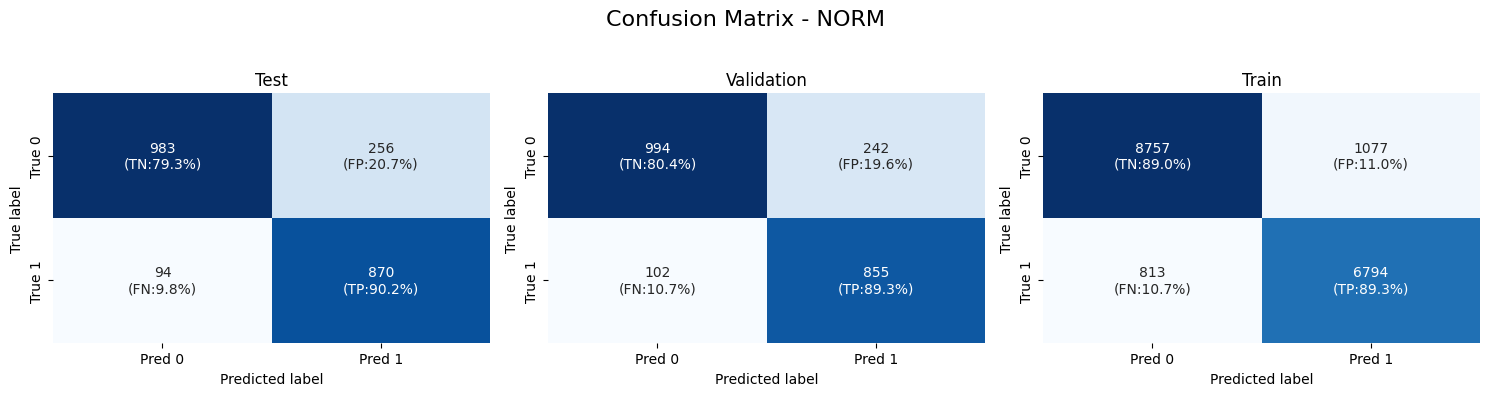

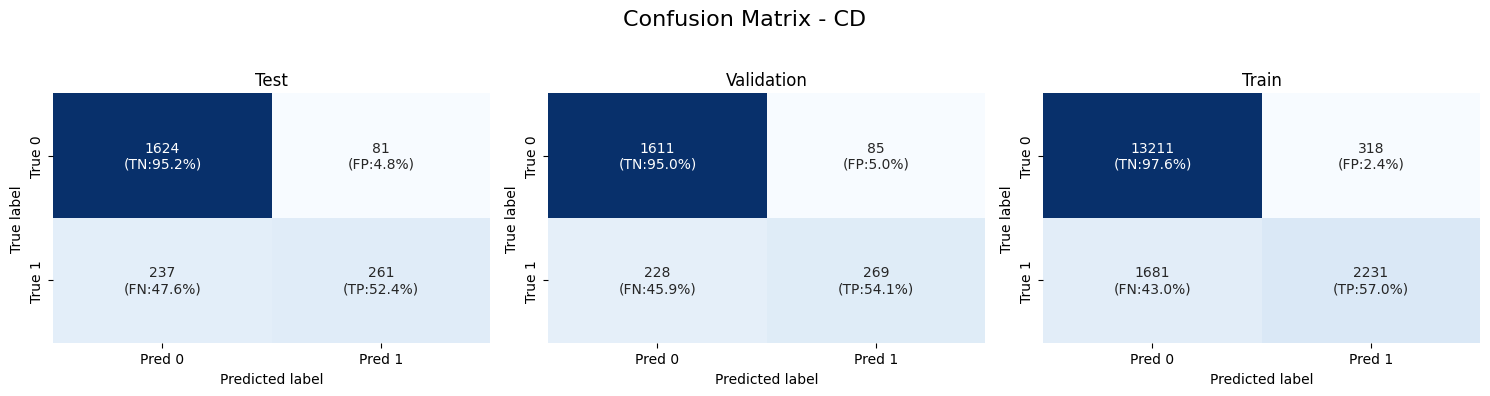

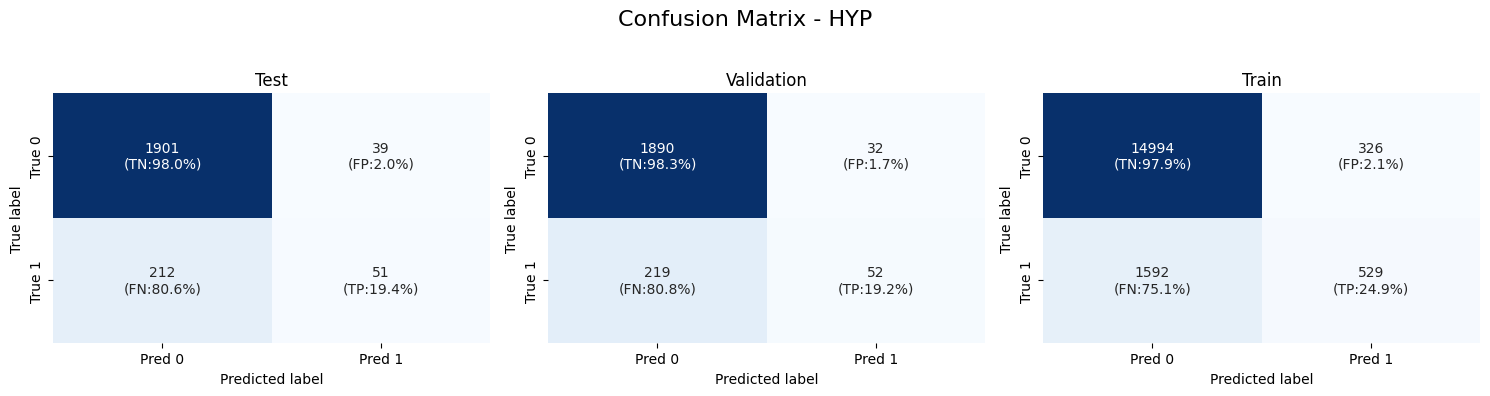

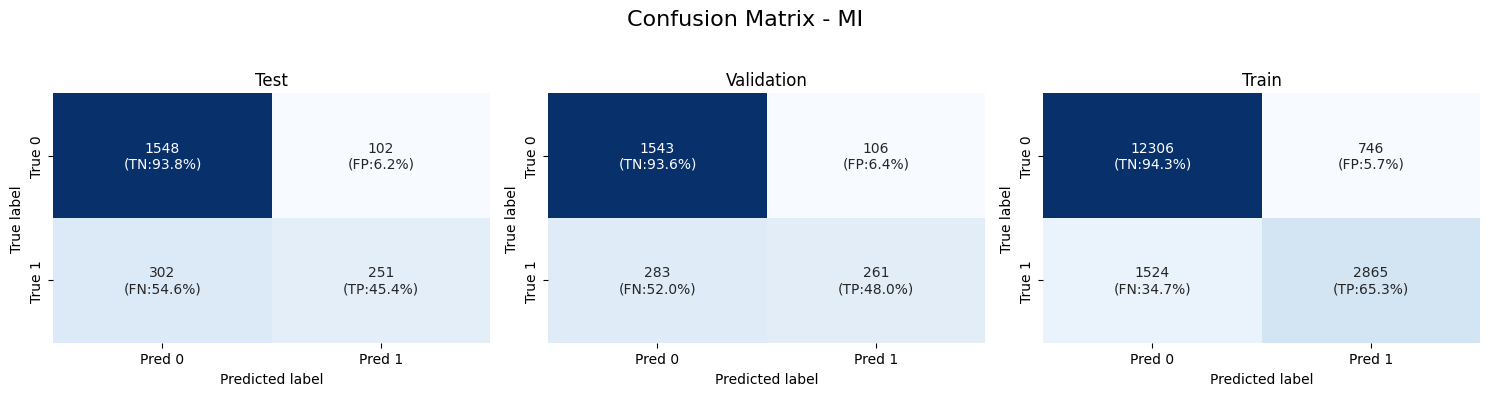

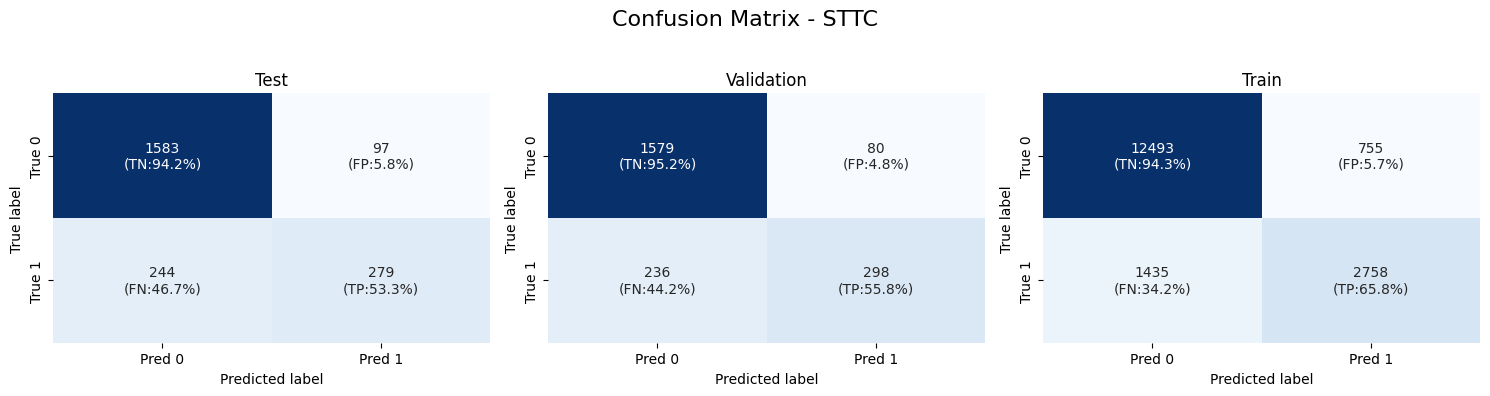

In [22]:
print("confusion_matrix (Test Set)")
#plot_confusion_matrix_per_class(targets_test, preds_test, list(classes_name.keys()))
set_names = ["Test", "Validation", "Train"]
plot_confusion_matrix_per_class_multi(
    [targets_test, targets_val, targets_train],
    [preds_test, preds_val, preds_train],
    class_names=list(label_map.keys()),
    set_names=set_names
)